# Базов Модел: Дърво на Решенията (Decision Tree)

Този notebook има за цел да създаде базов модел (baseline), с който да оценим качеството на подготвените данни. 
Използваме **Decision Tree Classifier**, тъй като е лесен за интерпретация и не изисква сложна настройка.

**Цели:**
1.  Да проверим дали данните са технически изправни за обучение.
2.  Да установим базови метрици (Accuracy, F1-Score), които по-сложните модели (Neural Networks) трябва да надминат.
3.  Да потвърдим кои характеристики моделът счита за важни (Feature Importance) и да ги сравним с Mutual Information анализа.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib

# Настройка на визуализациите
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Зареждане на Данните

Зареждаме вече обработените и балансирани (за Train) данни от папката `Data_prep`.

In [14]:
# Пътища към файловете (relative paths)
DATA_DIR = '../../Data_prep'

try:
    X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
    y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv')
    X_test = pd.read_csv(f'{DATA_DIR}/X_test.csv')
    y_test = pd.read_csv(f'{DATA_DIR}/y_test.csv')
    
    print("Данните са заредени успешно!")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
except FileNotFoundError:
    print("ГРЕШКА: Файловете не са намерени. Моля, проверете дали сте изпълнили Data Preparation стъпката.")

Данните са заредени успешно!
X_train shape: (143984, 21)
X_test shape: (10000, 21)


## 2. Инициализация и Обучение на Модела

Използваме стандартен `DecisionTreeClassifier`. 
Тъй като `X_train` е вече балансиран (чрез SMOTE), не е задължително да използваме `class_weight='balanced'`, но можем да го оставим по подразбиране.

In [15]:
# Инициализиране на модела
clf = DecisionTreeClassifier(random_state=42, max_depth=10) 
# max_depth=10 е сложен, за да избегнем прекалено преобучаване (overfitting) на базовия модел

# Обучение
print("Обучение на модела...")
clf.fit(X_train, y_train.values.ravel())
print("Обучението завърши.")

Обучение на модела...
Обучението завърши.


## 3. Оценка на Модела (Evaluation)

Тестваме модела върху **X_test**, който съдържа оригиналното (небалансирано) разпределение на данните. Това е най-честната оценка за реалното представяне.

In [16]:
# Прогнозиране
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Метрики
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      8999
           1       0.13      0.01      0.01      1001

    accuracy                           0.90     10000
   macro avg       0.52      0.50      0.48     10000
weighted avg       0.82      0.90      0.85     10000

Accuracy Score: 0.8966
ROC-AUC Score: 0.4916


### Матрица на объркването (Confusion Matrix)

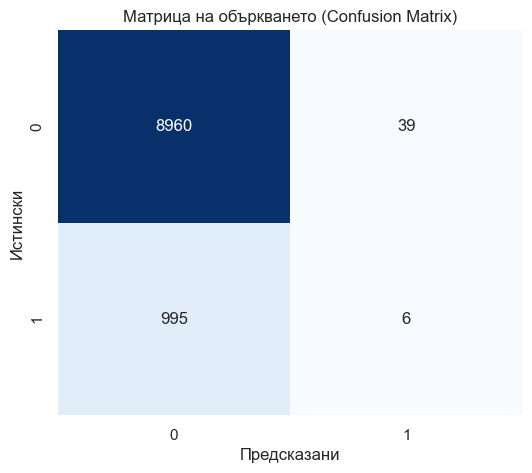

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Предсказани')
plt.ylabel('Истински')
plt.title('Матрица на объркването (Confusion Matrix)')
plt.show()

## 4. Важност на Характеристиките (Feature Importance)

Дърветата на решенията предоставят вграден метод за оценка на важността на всеки признак. Нека видим кои характеристики са били най-полезни за разделянето на класовете.

/var/folders/wt/0xpv1lcj3y1dqrxzbh47n3vh0000gn/T/ipykernel_23670/3896844851.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


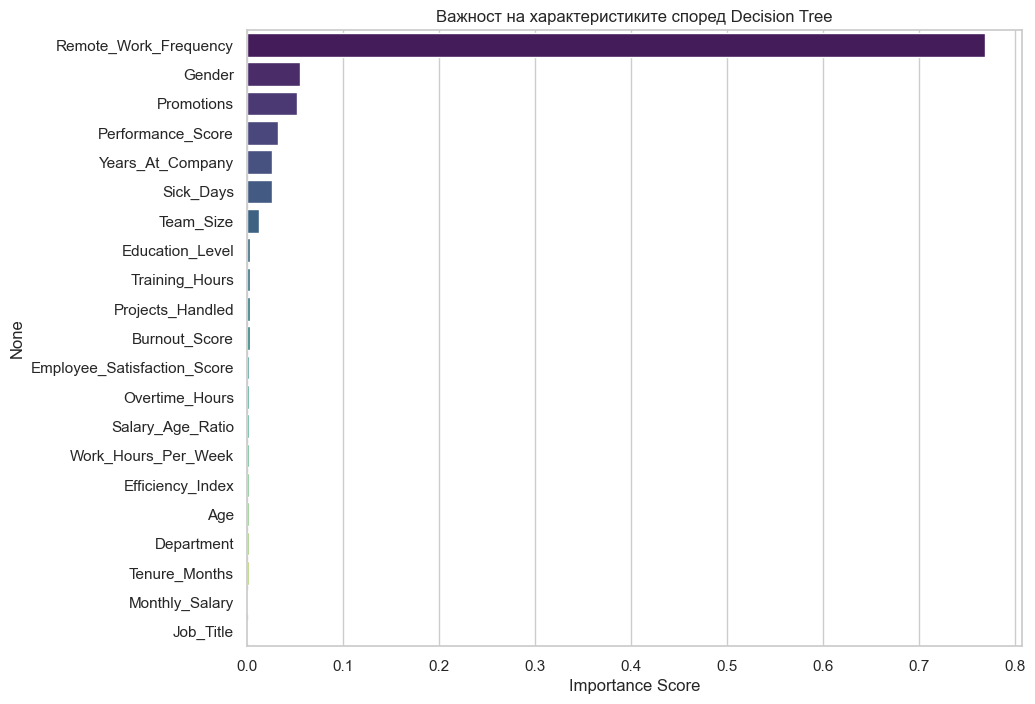

Топ 10 най-важни характеристики:
Remote_Work_Frequency    0.769414
Gender                   0.054605
Promotions               0.052329
Performance_Score        0.032106
Years_At_Company         0.025706
Sick_Days                0.025493
Team_Size                0.011909
Education_Level          0.003387
Training_Hours           0.003183
Projects_Handled         0.003149
dtype: float64


In [18]:
feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Важност на характеристиките според Decision Tree')
plt.xlabel('Importance Score')
plt.show()

print("Топ 10 най-важни характеристики:")
print(feature_importances.head(10))

## 5. Заключение

**Как да тълкуваме резултатите:**

1.  **Ако Accuracy е високо (> 90%), но Recall за клас 1 (Напуснали) е нисък:** Моделът просто предсказва "Не напуснал" за всички, защото те са мнозинство. Това не е добър модел.
2.  **Ако имаме добър F1-score за клас 1:** Това означава, че feature engineering-ът ни е бил успешен.
3.  **Сравнение с MI:** Вижте дали топ характеристиките тук (напр. `Tenure_Months`, `Burnout_Score`) съвпадат с тези от Mutual Information анализа. Ако да, това е силно потвърждение, че сме на прав път.